**Part A — Data preparation (must-have)**

Q1Load both datasets and document:
number of rows/columns
missing values / duplicates


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sentiment = pd.read_csv("/content/fear_greed_index.csv")
trades = pd.read_csv("/content/historical_data.csv")

print(sentiment.shape, trades.shape)
print("Sentiment\n" ,sentiment.head(5))
print("Data\n" ,trades.head(5))

print("Missing values")
print(sentiment.isnull().sum(),"\n");
print(trades.isnull().sum(),"\n")

print("Duplicate values")
print(sentiment.duplicated().sum(),"\n");
print(trades.duplicated().sum(),"\n")
sentiment.drop_duplicates(inplace=True)
trades.drop_duplicates(inplace=True)



(2644, 4) (211224, 16)
Sentiment
     timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
Data
                                       Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       

q2 Convert timestamps and align the datasets by date (daily level is fine).


In [3]:
print(sentiment.columns.tolist())
print(trades.columns.tolist())

['timestamp', 'value', 'classification', 'date']
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [4]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
trades['date'] = pd.to_datetime( trades['Timestamp IST'],  format='%d-%m-%Y %H:%M').dt.date
print("Invalid dates:", trades['date'].isnull().sum())

merged = pd.merge(trades, sentiment, on='date', how='inner')
print("Merged dataset shape:", merged.shape)
print("Sentiment range:", sentiment['date'].min(), "to", sentiment['date'].max())
print("Trades range:", trades['date'].min(), "to", trades['date'].max())
print("Merged range:", merged['date'].min(), "to", merged['date'].max())

Invalid dates: 0
Merged dataset shape: (211218, 20)
Sentiment range: 2018-02-01 to 2025-05-02
Trades range: 2023-05-01 to 2025-05-01
Merged range: 2023-05-01 to 2025-05-01


Q3 Create the key metrics you will analyze, for example:


In [5]:
merged['is_win'] = merged['Closed PnL'] > 0
merged['is_long'] = merged['Side'] == 'Long'
# confirm Long/Short or BUY/SELL
print(merged['Side'].unique())

['BUY' 'SELL']


In [6]:
print(merged.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'timestamp', 'value', 'classification', 'is_win', 'is_long']


In [7]:
# create all key metrics
merged['is_win'] = merged['Closed PnL'] > 0
merged['is_long'] = merged['Side'] == 'BUY'

# trader level summary
trader_summary = merged.groupby('Account').agg(
    total_pnl = ('Closed PnL', 'sum'),
    win_rate = ('is_win', 'mean'),
    avg_size = ('Size USD', 'mean'),
    num_trades = ('Closed PnL', 'count'),
    long_ratio = ('is_long', 'mean')
).reset_index()

# daily level summary
daily = merged.groupby(['date', 'classification']).agg(
    daily_pnl = ('Closed PnL', 'sum'),
    win_rate = ('is_win', 'mean'),
    avg_size = ('Size USD', 'mean'),
    num_trades = ('Closed PnL', 'count'),
    long_ratio = ('is_long', 'mean')
).reset_index()

print("Trader summary shape:", trader_summary.shape)
print("Daily summary shape:", daily.shape)

Trader summary shape: (32, 6)
Daily summary shape: (479, 7)


In [8]:
trader_summary.head()
daily.head()


print("Traders:", trader_summary.shape[0])
print("\nPnL range:", round(trader_summary['total_pnl'].min(), 2), "to", round(trader_summary['total_pnl'].max(), 2))
print("Win rate range:", round(trader_summary['win_rate'].min(), 2), "to", round(trader_summary['win_rate'].max(), 2))
print("Avg trade size range:", round(trader_summary['avg_size'].min(), 2), "to", round(trader_summary['avg_size'].max(), 2))
print("Trades range:", trader_summary['num_trades'].min(), "to", trader_summary['num_trades'].max())
print("Long ratio range:", round(trader_summary['long_ratio'].min(), 2), "to", round(trader_summary['long_ratio'].max(), 2))

Traders: 32

PnL range: -167621.12 to 2143382.6
Win rate range: 0.23 to 0.81
Avg trade size range: 507.63 to 34396.58
Trades range: 332 to 40184
Long ratio range: 0.22 to 0.69


**PartB**

Q1 Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?


In [9]:
# drawdown proxy - cumulative pnl drawdown
daily = daily.sort_values('date')
daily['cumulative_pnl'] = daily['daily_pnl'].cumsum()
daily['rolling_max'] = daily['cumulative_pnl'].cummax()
daily['drawdown'] = daily['cumulative_pnl'] - daily['rolling_max']

print(daily.groupby('classification')[['daily_pnl', 'win_rate', 'drawdown']].mean().round(3))

                daily_pnl  win_rate   drawdown
classification                                
Extreme Fear    52793.589     0.327 -36589.077
Extreme Greed   23817.292     0.467  -2727.851
Fear            36891.818     0.329 -38135.023
Greed           11140.566     0.336 -21080.875
Neutral         19297.324     0.332 -30967.961


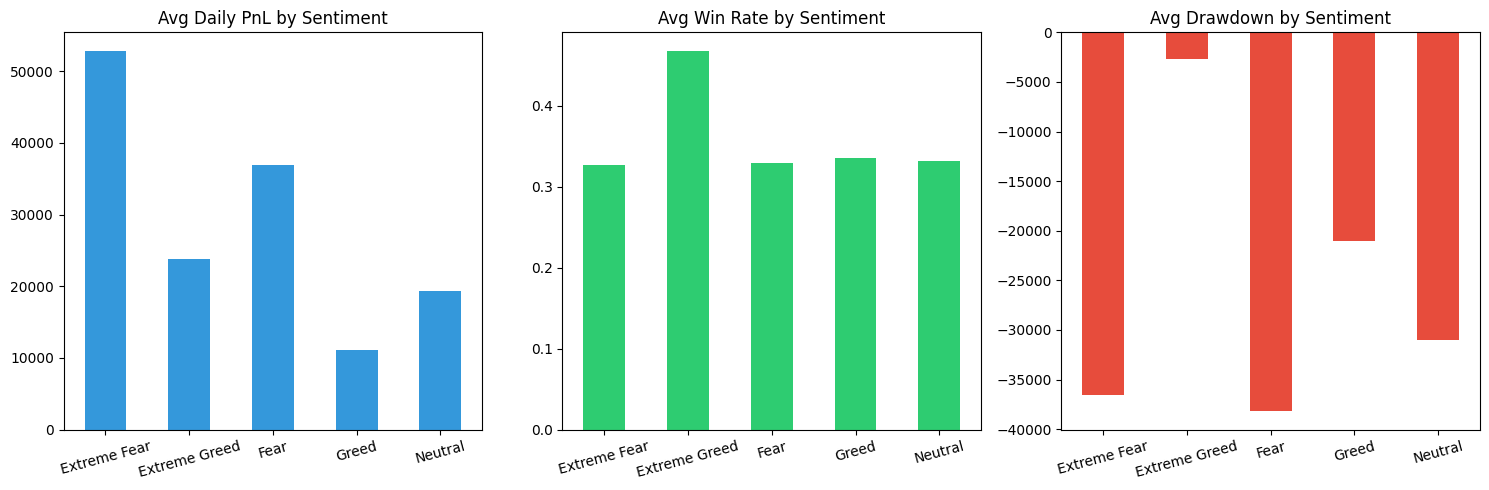

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

daily.groupby('classification')['daily_pnl'].mean().plot(
    kind='bar', ax=axes[0], color='#3498db', rot=15)
axes[0].set_title('Avg Daily PnL by Sentiment')
axes[0].set_xlabel('')


daily.groupby('classification')['win_rate'].mean().plot(
    kind='bar', ax=axes[1], color='#2ecc71', rot=15)
axes[1].set_title('Avg Win Rate by Sentiment')
axes[1].set_xlabel('')

daily.groupby('classification')['drawdown'].mean().plot(
    kind='bar', ax=axes[2], color='#e74c3c', rot=15)
axes[2].set_title('Avg Drawdown by Sentiment')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

Q1 Findings-

*   Extreme Fear days show the highest PnL (~53k) but also the worst drawdowns (-38k), indicating a
high risk high reward environment driven by a few large wins rather than consistency.

*   Extreme Greed is the safest and most consistent — highest win rate (0.47) and minimal drawdown
(-2.7k), meaning traders perform better and lose less during these periods.
*   Win rate stays flat at ~0.33 across Fear, Greed and Neutral, suggesting regular sentiment shifts
don't meaningfully impact how often traders win.





q2-Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?

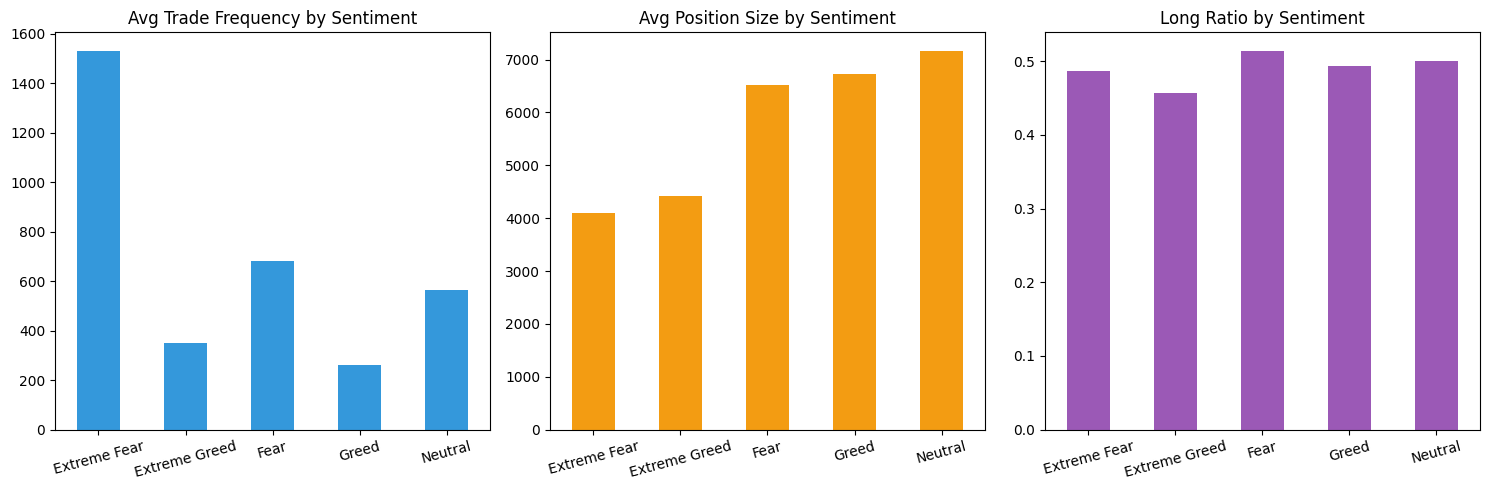

In [13]:
daily.groupby('classification')[['num_trades', 'avg_size', 'long_ratio']].mean().round(3)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

daily.groupby('classification')['num_trades'].mean().plot(
    kind='bar', ax=axes[0], color='#3498db', rot=15)
axes[0].set_title('Avg Trade Frequency by Sentiment')
axes[0].set_xlabel('')



daily.groupby('classification')['avg_size'].mean().plot(
    kind='bar', ax=axes[1], color='#f39c12', rot=15)
axes[1].set_title('Avg Position Size by Sentiment')
axes[1].set_xlabel('')

daily.groupby('classification')['long_ratio'].mean().plot(
    kind='bar', ax=axes[2], color='#9b59b6', rot=15)
axes[2].set_title('Long Ratio by Sentiment')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

Q2 Findings:

* Trade frequency spikes massively during Extreme Fear ( approx 1500 trades/day)
compared to Greed (~270),
suggesting traders react strongly to panic by trading much more frequently.

* Position size is smallest during fear periods (~4100 on Extreme Fear) and largest during Neutral
and Greed days (~7200), meaning traders are cautious with size when the market is fearful.

* Long ratio stays fairly flat across all sentiments (0.46 - 0.52), suggesting traders don't
significantly shift their long/short bias based on sentiment — direction bias is relatively
sentiment-neutral.

* Overall: traders react to fear by trading more often but with smaller positions, which is a
cautious but active response to market panic.

Question 3 Identify 2–3 segments (examples):
high leverage vs low leverage traders
frequent vs infrequent traders
consistent winners vs inconsistent traders


In [15]:
# segment 1 - frequent vs infrequent traders
median_trades = trader_summary['num_trades'].median()
trader_summary['freq_segment'] = trader_summary['num_trades'].apply(
    lambda x: 'Frequent' if x >= median_trades else 'Infrequent'
)

# segment 2 - high vs low position size
median_size = trader_summary['avg_size'].median()
trader_summary['size_segment'] = trader_summary['avg_size'].apply(
    lambda x: 'High Size' if x >= median_size else 'Low Size'
)

# segment 3 - consistent winners vs inconsistent
def label_winner(row):
    if row['win_rate'] >= 0.55 and row['total_pnl'] > 0:
        return 'Consistent Winner'
    elif row['win_rate'] < 0.45 and row['total_pnl'] < 0:
        return 'Consistent Loser'
    else:
        return 'Inconsistent'

trader_summary['winner_segment'] = trader_summary.apply(label_winner, axis=1)


print("Frequent vs Infrequent:")
print(trader_summary.groupby('freq_segment')[['total_pnl', 'win_rate', 'avg_size']].mean().round(2))
print("\nHigh vs Low Position Size:")
print(trader_summary.groupby('size_segment')[['total_pnl', 'win_rate', 'num_trades']].mean().round(2))
print("\nWinner Segments:")
print(trader_summary.groupby('winner_segment')[['total_pnl', 'win_rate', 'num_trades', 'avg_size']].mean().round(2))

Frequent vs Infrequent:
              total_pnl  win_rate  avg_size
freq_segment                               
Frequent      496527.66      0.41   7912.91
Infrequent    144377.77      0.39   4099.61

High vs Low Position Size:
              total_pnl  win_rate  num_trades
size_segment                                 
High Size     416805.97      0.36     4185.31
Low Size      224099.47      0.44     9015.81

Winner Segments:
                   total_pnl  win_rate  num_trades  avg_size
winner_segment                                              
Consistent Loser  -119028.66      0.34     4205.00   5548.84
Consistent Winner  225970.95      0.69     5155.00   2333.73
Inconsistent       358592.94      0.39     6874.93   6301.26


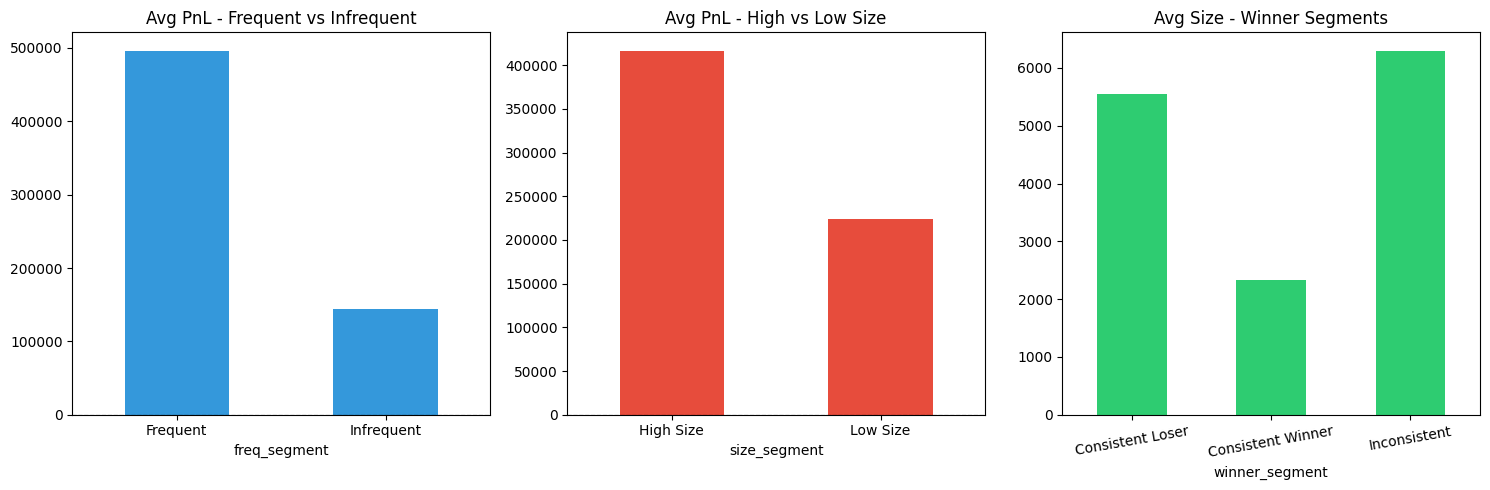

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

trader_summary.groupby('freq_segment')['total_pnl'].mean().plot(
    kind='bar', ax=axes[0], color='#3498db', rot=0)
axes[0].set_title('Avg PnL - Frequent vs Infrequent')
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)

trader_summary.groupby('size_segment')['total_pnl'].mean().plot(
    kind='bar', ax=axes[1], color='#e74c3c', rot=0)
axes[1].set_title('Avg PnL - High vs Low Size')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)

trader_summary.groupby('winner_segment')['avg_size'].mean().plot(
    kind='bar', ax=axes[2], color='#2ecc71', rot=10)
axes[2].set_title('Avg Size - Winner Segments')

plt.tight_layout()
plt.show()

q3 Segment Findings:

* Frequent traders significantly outperform infrequent ones (496k vs 144k PnL) with a slightly
higher win rate (0.41 vs 0.39), suggesting that staying active in the market compounds returns
over time.

* High size traders make more money (416k vs 224k) but have a lower win rate (0.36 vs 0.44),
meaning they win less often but their winning trades are large enough to overcome the losses.
Low size traders are more accurate but don't capitalize enough on their wins.

* Consistent winners stand out clearly — they have the highest win rate (0.69) but the smallest
average position size (2333), meaning they win by being right more often, not by betting big.
Consistent losers do the opposite — larger positions (5548) with a low win rate (0.34),
essentially betting big and losing often.

Question 4 Provide at least 3 insights backed by charts/tables.


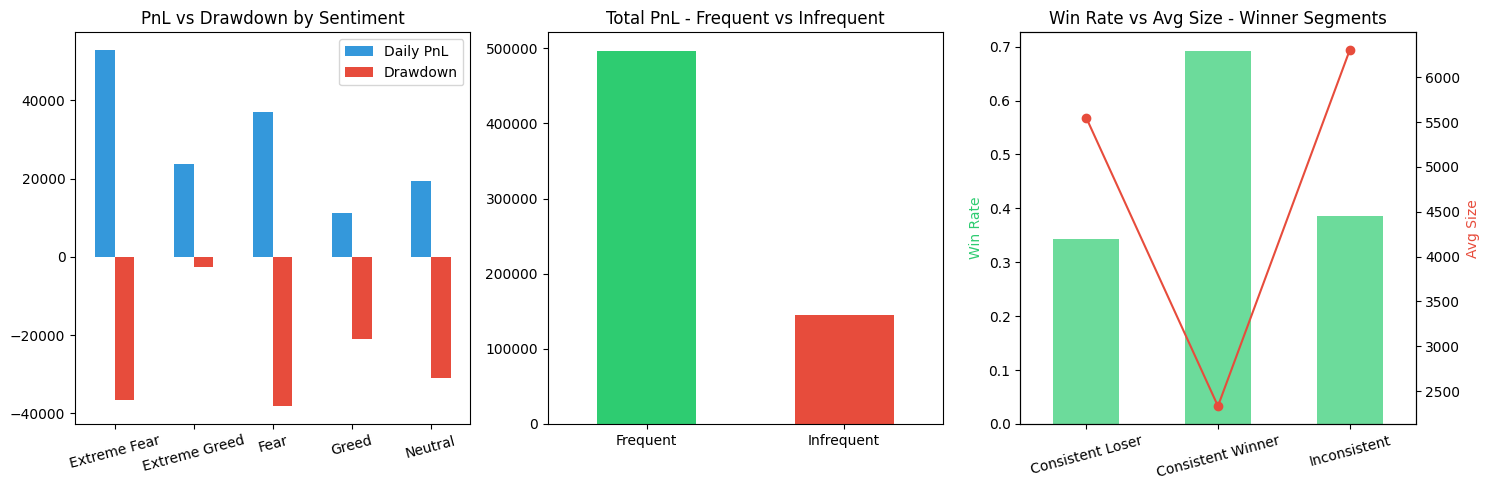

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# insight 1 - pnl vs drawdown on fear vs greed
daily.groupby('classification')[['daily_pnl', 'drawdown']].mean().plot(
    kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], rot=15)
axes[0].set_title('PnL vs Drawdown by Sentiment')
axes[0].set_xlabel('')
axes[0].legend(['Daily PnL', 'Drawdown'])

# insight 2 - frequent vs infrequent pnl
trader_summary.groupby('freq_segment')['total_pnl'].mean().plot(
    kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], rot=0)
axes[1].set_title('Total PnL - Frequent vs Infrequent')
axes[1].set_xlabel('')

# insight 3 - winner segment win rate vs avg size
winner_stats = trader_summary.groupby('winner_segment')[['win_rate', 'avg_size']].mean()
ax2 = axes[2].twinx()
winner_stats['win_rate'].plot(kind='bar', ax=axes[2], color='#2ecc71', alpha=0.7, rot=15, label='Win Rate')
winner_stats['avg_size'].plot(kind='line', ax=ax2, color='#e74c3c', marker='o', label='Avg Size')
axes[2].set_title('Win Rate vs Avg Size - Winner Segments')
axes[2].set_xlabel('')
axes[2].set_ylabel('Win Rate', color='#2ecc71')
ax2.set_ylabel('Avg Size', color='#e74c3c')
plt.tight_layout()
plt.show()

Insight 1 - Extreme Fear is high risk high reward:
Extreme Fear days show the highest PnL (~53k) but worst drawdowns (-38k). Traders make money
on these days but through a few large wins, not consistency. Win rate on Fear days is only 0.33.

Insight 2 - Trade more, win more:
Frequent traders generate 3x more PnL than infrequent traders (496k vs 144k). During Extreme
Fear, trade frequency spikes to ~1500/day vs ~270 on Greed days, showing active traders
capitalize on volatile markets better.

Insight 3 - Bet smaller, win more often:
Consistent winners have the smallest avg position size (2333) but the highest win rate (0.69).
High size traders have a win rate of only 0.36. Bigger bets do not mean better results —
accuracy matters more than position size.

Part C — “Actionable output”


Strategy 1 - Trade more frequently but with smaller sizes during Fear days:
During Extreme Fear, trade frequency is highest (approx 1500/day) and PnL is also highest ( approx 53k).
Infrequent traders miss out on these opportunities entirely. However, position sizes should
be kept small since drawdowns are worst during Fear.
Rule: During Fear days, increase trade frequency but cap position size below your average.

Strategy 2 - Follow the Consistent Winner playbook regardless of sentiment:
Consistent winners maintain a high win rate (0.69) with small position sizes (2333) across
all market conditions. They don't rely on sentiment to make decisions.
Rule: Keep position sizes small, focus on accuracy over bet size, and stay active.
Do not increase position size during Greed expecting bigger wins — the data shows it backfires.

Bonus — Clustering

          total_pnl  win_rate  avg_size  num_trades
cluster                                            
0.0       190869.84      0.51   3061.31     3010.30
1.0       390628.98      0.40  24666.44     8219.33
2.0      1379964.19      0.40   6263.04    19981.75
3.0       110269.65      0.33   4169.06     5102.00


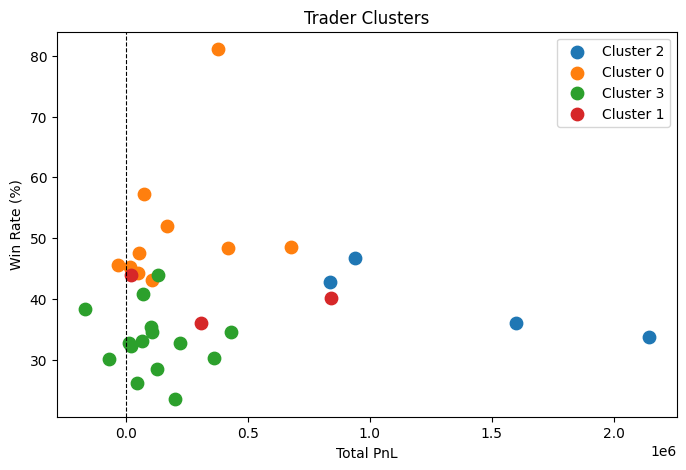

In [18]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = trader_summary[['total_pnl', 'win_rate', 'avg_size', 'num_trades', 'long_ratio']].dropna()

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
trader_summary.loc[features.index, 'cluster'] = kmeans.fit_predict(scaled)

print(trader_summary.groupby('cluster')[['total_pnl', 'win_rate', 'avg_size', 'num_trades']].mean().round(2))

plt.figure(figsize=(8, 5))
for cluster in trader_summary['cluster'].unique():
    subset = trader_summary[trader_summary['cluster'] == cluster]
    plt.scatter(subset['total_pnl'], subset['win_rate'] * 100, label=f'Cluster {int(cluster)}', s=80)

plt.xlabel('Total PnL')
plt.ylabel('Win Rate (%)')
plt.title('Trader Clusters')
plt.legend()
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.show()

Cluster 0 - Consistent Moderate Traders: Best win rate (0.51), small position sizes (3061),
moderate trade count. These are disciplined traders who win more often than they lose.

Cluster 1 - High Size Low Accuracy: Largest position sizes (24666) but low win rate (0.40).
Big bettors who don't win often enough to justify the risk.

Cluster 2 - High Frequency High PnL: Highest total PnL (1.37M) and most trades (19981) but
low win rate (0.40). They make money through volume not accuracy.

Cluster 3 - Struggling Traders: Lowest win rate (0.33), low PnL (110k), moderate activity.
No clear edge in either accuracy or volume.

              precision    recall  f1-score   support

           0       0.54      0.39      0.45       174
           1       0.68      0.80      0.74       288

    accuracy                           0.65       462
   macro avg       0.61      0.59      0.59       462
weighted avg       0.63      0.65      0.63       462



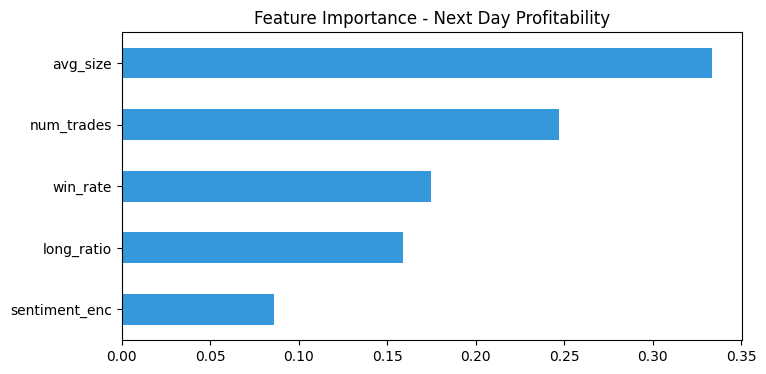

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# create features
model_df = merged.groupby(['Account', 'date']).agg(
    pnl = ('Closed PnL', 'sum'),
    win_rate = ('is_win', 'mean'),
    avg_size = ('Size USD', 'mean'),
    num_trades = ('Closed PnL', 'count'),
    long_ratio = ('is_long', 'mean')
).reset_index()

model_df = model_df.merge(daily[['date', 'classification']], on='date', how='left')
model_df = model_df.sort_values(['Account', 'date'])

# target - next day profitable or not
model_df['next_day_pnl'] = model_df.groupby('Account')['pnl'].shift(-1)
model_df.dropna(subset=['next_day_pnl'], inplace=True)
model_df['target'] = (model_df['next_day_pnl'] > 0).astype(int)

# encode sentiment
model_df['sentiment_enc'] = model_df['classification'].map({
    'Extreme Fear': 0, 'Fear': 1, 'Neutral': 2, 'Greed': 3, 'Extreme Greed': 4
})

X = model_df[['win_rate', 'avg_size', 'num_trades', 'long_ratio', 'sentiment_enc']]
y = model_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))


feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
feat_imp.plot(kind='barh', color='#3498db', figsize=(8, 4))
plt.title('Feature Importance - Next Day Profitability')
plt.show()

Predictive Model

The model achieves 65% overall accuracy but this is misleading. It predicts profitable days
well (f1 = 0.74) but struggles badly with loss days (f1 = 0.45, precision = 0.54). This means
the model is mostly just predicting "profitable" for most cases which happens to be right
more often since winners dominate the dataset.

Sentiment encoding has the lowest feature importance (0.09), confirming that market sentiment
alone is a poor predictor of next day profitability. Position size and trade frequency are far
more predictive.

The model in its current form is not reliable enough to trade on. It would need more features
like price action, historical win streaks, or market volatility to improve meaningfully.

## Summary

### Methodology
I merged the Fear/Greed sentiment data (2,644 days, Feb 2018 - May 2025) with Hyperliquid
trade records on a daily level. After aligning timestamps, we had 211,218 matched trades
across 32 unique traders over 479 trading days (May 2023 - May 2025). No missing values or
duplicates were found in either dataset. Key metrics built include daily PnL, win rate,
average position size, trade frequency and long/short ratio at both trader and daily level.
Traders were segmented three ways — frequent vs infrequent (median split), high vs low
position size (median split), and consistent winners vs losers (win rate >= 0.55 and
positive total PnL).

### What I found

Extreme Fear days generate the highest average daily PnL (52,793) but also the worst
drawdowns (-36,589). Win rate on Fear days is only 0.327 — so most trades are still losing,
a few large wins are driving the average up. Extreme Greed is the opposite — lower PnL
(23,817) but highest win rate (0.467) and almost no drawdown (-2,727). Regular Greed days
are actually the weakest overall with just 11,140 avg daily PnL and a 0.336 win rate.

Trader behaviour does shift with sentiment. On Extreme Fear days trade frequency spikes to
approx 1,500 trades/day vs ~270 on Greed days, but position sizes shrink — traders are getting
more active but more cautious when the market panics.

The segmentation told the clearest story. Frequent traders (>6,874 trades) generate 3.4x
more total PnL than infrequent ones (496,527 vs 144,377) despite only a slightly higher
win rate (0.41 vs 0.39). Consistent winners have a 0.69 win rate with an avg position size
of just dollar 2,333, the smallest of any segment. Consistent losers do the opposite: avg size
of dollar 5,548 with a 0.34 win rate. High size traders (dollar 24,666 avg, Cluster 1) have a win rate
of only 0.40 while the best performing cluster (Cluster 2, 1.37M total PnL) trades the
most frequently at ~19,981 trades with moderate sizes ($6,263).

### Strategy Recommendations

Strategy 1 — On Fear days, trade more but keep sizes small. Extreme Fear has the highest
PnL potential (52,793 avg) and trade activity spikes to ~1,500/day, but drawdowns hit
-36,589 when things go wrong. Staying active with position sizes closer to $4,000 captures
the opportunity without the blowup risk.

Strategy 2 — Follow the consistent winner playbook. Win rate 0.69, avg size $2,333,
avg 5,155 trades. The data is clear — accuracy and frequency beat bet size every time.
The predictive model confirmed this with position size (0.33) and trade frequency (0.25)
as the top two features vs sentiment at just 0.09.

### On the model
The Random Forest model hit 65% accuracy but it's not as good as it sounds. It predicts
profitable days well (f1 = 0.74, recall = 0.80) but struggles with losing days (precision
= 0.54, f1 = 0.45). With only 32 traders and 5 features the model is limited. The main
takeaway is that sentiment scored the lowest feature importance (0.09) — your trading
behaviour predicts tomorrow far better than how the market feels today.